# 05 — Final Model: Tuning, Frozen Decisions, and the One-Time Holdout Check

`03_model_extension.ipynb` found LightGBM the leading candidate (PR-AUC 0.240, ahead of Random
Forest and XGBoost), and `04_error_analysis.ipynb`'s error analysis found the three tree models
agree on 71% of fraud clients -- hard given the current features, not a model-choice problem --
and recommended proceeding to hyperparameter tuning rather than model-swapping or blind
ensembling.

This notebook is the last step: tune LightGBM, decide -- with evidence, not by default -- whether
a LightGBM+Random Forest ensemble is worth adopting, freeze the approach using only
cross-validation evidence from the development pool, and then evaluate the frozen pipeline
**exactly once** on the held-out `test_client_features.csv` split. It also re-checks whether 04's
headline finding (a severe recall blind spot for short-history clients) replicates on that
untouched split, and formally records the leakage-features decision `01_eda.ipynb` Step 7 raised.

> **⚠️ Partial follow-through on 04's priority order.** This notebook went straight to tuning
> first (Steps 3-4) -- the "ahead of tuning" ordering `04_error_analysis.ipynb` recommended
> wasn't followed, and no relative/normalized feature versions were tried anywhere here. What
> is done: Step 8 re-checks the blind spot on the untouched holdout and confirms it's real
> (shortest quintile recall collapses to 5.6%), and the Results/Interpretation/Limitations
> sections restate the caveat explicitly. This notebook's own Limitations section already
> admits the gap: "Any future iteration should prioritize new signal for short-history
> clients... over further tuning of this model family" -- i.e. this recommendation is still
> outstanding.

## Imports and constants

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from lightgbm import LGBMClassifier
from sklearn import set_config
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier

pd.set_option("display.max_columns", 100)

# Keep every ColumnTransformer's output a pandas DataFrame (not a numpy array) so the
# LightGBM-native-categorical variant in Step 2 keeps its `category` dtype -- a global config
# survives RandomizedSearchCV's internal cloning in Step 4, whereas per-transformer
# `.set_output()` does not (it's an instance attribute, and `clone()` only copies constructor
# params).
set_config(transform_output="pandas")

DATA_DIR = Path("data")
PROCESSED_DIR = DATA_DIR / "processed"
TRAIN_FEATURES_PATH = PROCESSED_DIR / "train_client_features.csv"
TEST_FEATURES_PATH = PROCESSED_DIR / "test_client_features.csv"

RSEED = 42  # same seed 01_eda.ipynb / 02_baseline_model.ipynb / 03_model_extension.ipynb / 04_error_analysis.ipynb use
N_SPLITS = 5
TOP_K_SHARE = 0.10  # the top-10% cutoff 04_error_analysis.ipynb uses for its per-model flags/segment checks -- kept here only to feed Step 8's blind-spot replication check, not as a reported headline metric

for path in [TRAIN_FEATURES_PATH, TEST_FEATURES_PATH]:
    if not path.exists():
        raise FileNotFoundError(
            f"Missing {path}. Run 01_eda.ipynb with SAVE_CSV_FILE=true first "
            "to produce the cleaned, client-level feature tables this notebook loads."
        )

## Step 1 — Load the development pool and the holdout, with an honest caveat

This notebook uses the same two client-level feature tables `02_baseline_model.ipynb`
introduced: `train_client_features.csv` (the 80% development pool -- every cross-validation and
tuning decision below uses only this) and `test_client_features.csv` (the 20% holdout).

**Caveat, stated plainly:** `test_client_features.csv` is not a pristine, never-touched estimate.
`02_baseline_model.ipynb` already fit-and-scored a dummy model and logistic regression on it as a
"final internal check" -- *before* 03's six-model comparison or 04's error analysis existed,
i.e. before this project's modeling approach was actually frozen. This notebook's holdout number
in Step 7 is the final look at that same split, not the first one. It's still a genuinely
out-of-sample check (nothing since 02 has used it for any decision), but it should be reported
as that, not as a completely untouched generalization estimate.

In [2]:
df_train = pd.read_csv(TRAIN_FEATURES_PATH)
df_test = pd.read_csv(TEST_FEATURES_PATH)

for frame in [df_train, df_test]:
    frame["client_id"] = frame["client_id"].astype("string")
    frame["target"] = frame["target"].astype("int8")

assert set(df_train["client_id"]).isdisjoint(df_test["client_id"])

overview = pd.DataFrame({
    "clients": [len(df_train), len(df_test)],
    "fraud_cases": [int(df_train["target"].sum()), int(df_test["target"].sum())],
    "fraud_rate": [df_train["target"].mean(), df_test["target"].mean()],
}, index=["train (development pool)", "test (holdout)"])
display(overview)

,clients,fraud_cases,fraud_rate
train (development pool),108394,6053,0.055843
test (holdout),27099,1513,0.055832


## Step 2 — Two preprocessing variants for LightGBM

Variant A is the identical `ColumnTransformer` every notebook so far has used: median-impute and
scale the 12 numeric features, one-hot encode `client_catg`/`disrict`/`region`. Variant B tests
`03_model_extension.ipynb`'s "cheap follow-up variant" suggestion: LightGBM can use categorical
columns natively (no one-hot) if they're typed as pandas `category` -- skipping one-hot removes
several dozen sparse dummy columns and lets LightGBM choose its own categorical splits. Random
Forest and XGBoost keep Variant A only -- 03's next-steps only proposed the native variant for
LightGBM, and this notebook doesn't retune them (see Step 3).

In [3]:
categorical_features = ["client_catg", "region", "disrict"]
numeric_features = [
    "invoice_count", "active_days", "mean_consumption", "zero_consumption_rate",
    "elec_share", "mean_invoice_gap_days", "backwards_index_rate", "meter_count",
    "mean_monthly_submission_index_delta", "backward_submission_rate",
    "large_mismatch_count", "reconciliation_gap_abs_mean",
]
model_features = numeric_features + categorical_features

X = df_train[model_features]
y = df_train["target"]
y_values = y.to_numpy()

# Variant A -- one-hot, identical to 02/03/04.
preprocessor_onehot = ColumnTransformer([
    ("numeric", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ]), numeric_features),
    ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
])

# Variant B -- LightGBM-native categoricals: numeric branch imputes/scales, categoricals pass
# through untouched as pandas `category` dtype so LGBMClassifier auto-detects them.
X_native = X.copy()
for col in categorical_features:
    X_native[col] = X_native[col].astype("category")

preprocessor_native = ColumnTransformer([
    ("numeric", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ]), numeric_features),
    ("categorical", "passthrough", categorical_features),
])

cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RSEED)

## Step 3 — Fresh, same-environment reference numbers (untuned)

Recomputing LightGBM/Random Forest/XGBoost's untuned cross-validated numbers here, in this
notebook's own run, rather than quoting `03_model_extension.ipynb`'s historical results -- this
session already saw those drift slightly from a live rerun in `04_error_analysis.ipynb` (package
version differences), so a same-run baseline is what tuning lift should actually be measured
against. Random Forest and XGBoost stay untuned throughout this notebook: 03's own "Next steps"
say to keep them as references and revisit them only if justified, and 04's error analysis (71%
identical verdicts across all three models) didn't surface that justification.

In [4]:
scale_pos_weight = (y == 0).sum() / (y == 1).sum()

reference_specs = {
    "lightgbm_untuned": LGBMClassifier(class_weight="balanced", random_state=RSEED, n_jobs=-1, verbosity=-1),
    "random_forest": RandomForestClassifier(class_weight="balanced", random_state=RSEED, n_jobs=-1),
    "xgboost": XGBClassifier(
        scale_pos_weight=scale_pos_weight, eval_metric="logloss", random_state=RSEED, n_jobs=-1
    ),
}

reference_oof = {}
reference_rows = {}
for name, model in reference_specs.items():
    pipeline = Pipeline([("preprocess", preprocessor_onehot), ("model", model)])
    proba = cross_val_predict(pipeline, X, y, cv=cv, method="predict_proba")[:, 1]
    reference_oof[name] = proba
    reference_rows[name] = {
        "pr_auc": average_precision_score(y_values, proba),
        "roc_auc": roc_auc_score(y_values, proba),
    }
    print(f"done: {name}")

reference_summary = pd.DataFrame(reference_rows).T
display(reference_summary)

done: lightgbm_untuned


done: random_forest


done: xgboost


,pr_auc,roc_auc
lightgbm_untuned,0.235339,0.825991
random_forest,0.216596,0.809263
xgboost,0.222403,0.802875


## Step 4 — Hyperparameter tuning of LightGBM

`RandomizedSearchCV` rather than an exhaustive `GridSearchCV` -- cheaper for a search this wide --
scored on `average_precision`, same 5-fold CV/seed as everywhere else in this project.
`class_weight="balanced"` stays fixed (not searched), consistent with every other notebook's
methodology. Run once for each preprocessing variant from Step 2; the winner is whichever gets
the higher CV PR-AUC.

In [5]:
param_distributions = {
    "model__n_estimators": [100, 200, 300, 500, 800],
    "model__num_leaves": [15, 31, 63, 127],
    "model__max_depth": [-1, 4, 6, 8, 10],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "model__min_child_samples": [5, 10, 20, 50, 100],
    "model__subsample": [0.6, 0.8, 1.0],
    "model__colsample_bytree": [0.6, 0.8, 1.0],
    "model__reg_alpha": [0.0, 0.1, 1.0, 5.0],
    "model__reg_lambda": [0.0, 0.1, 1.0, 5.0],
}
N_SEARCH_ITER = 30


def tune_lightgbm(preprocessor, features, label):
    pipeline = Pipeline([
        ("preprocess", preprocessor),
        ("model", LGBMClassifier(class_weight="balanced", random_state=RSEED, n_jobs=-1, verbosity=-1)),
    ])
    search = RandomizedSearchCV(
        pipeline, param_distributions, n_iter=N_SEARCH_ITER, scoring="average_precision",
        cv=cv, random_state=RSEED, n_jobs=1, refit=True,
    )
    search.fit(features, y)
    print(f"{label}: best CV PR-AUC = {search.best_score_:.4f}")
    print(f"{label}: best params = {search.best_params_}")
    return search


search_onehot = tune_lightgbm(preprocessor_onehot, X, "LightGBM (one-hot)")
search_native = tune_lightgbm(preprocessor_native, X_native, "LightGBM (native categorical)")

tuning_results = pd.DataFrame({
    "variant": ["one-hot", "native categorical"],
    "cv_pr_auc": [search_onehot.best_score_, search_native.best_score_],
}).set_index("variant")
print("\nTuned LightGBM: preprocessing variant comparison")
display(tuning_results)
print(f"\nUntuned LightGBM baseline (Step 3): {reference_rows['lightgbm_untuned']['pr_auc']:.4f}")

winning_search = search_onehot if search_onehot.best_score_ >= search_native.best_score_ else search_native
winning_variant = "one-hot" if winning_search is search_onehot else "native categorical"
winning_features = X if winning_variant == "one-hot" else X_native
winning_preprocessor = preprocessor_onehot if winning_variant == "one-hot" else preprocessor_native
print(f"\nWinning variant: {winning_variant} (best params: {winning_search.best_params_})")

# best_estimator_ is already refit on ALL of (X, y) -- exactly what Step 7 needs to score the
# holdout with, no extra full-data fit required there. For an honest out-of-fold score here
# (needed for the ensemble check in Step 5), rebuild an unfit pipeline with the same best params
# and run cross_val_predict -- using best_estimator_.predict_proba(X) directly would be in-sample.
best_params = {k.split("__", 1)[1]: v for k, v in winning_search.best_params_.items()}
tuned_lightgbm_cv_pipeline = Pipeline([
    ("preprocess", winning_preprocessor),
    ("model", LGBMClassifier(
        class_weight="balanced", random_state=RSEED, n_jobs=-1, verbosity=-1, **best_params
    )),
])
tuned_lightgbm_oof = cross_val_predict(
    tuned_lightgbm_cv_pipeline, winning_features, y, cv=cv, method="predict_proba"
)[:, 1]
tuned_lightgbm_pr_auc = average_precision_score(y_values, tuned_lightgbm_oof)
tuned_lightgbm_roc_auc = roc_auc_score(y_values, tuned_lightgbm_oof)
print(
    f"\nTuned LightGBM ({winning_variant}) OOF: "
    f"PR-AUC={tuned_lightgbm_pr_auc:.4f}, ROC-AUC={tuned_lightgbm_roc_auc:.4f}"
)

LightGBM (one-hot): best CV PR-AUC = 0.2478
LightGBM (one-hot): best params = {'model__subsample': 1.0, 'model__reg_lambda': 5.0, 'model__reg_alpha': 5.0, 'model__num_leaves': 127, 'model__n_estimators': 300, 'model__min_child_samples': 50, 'model__max_depth': -1, 'model__learning_rate': 0.03, 'model__colsample_bytree': 1.0}


LightGBM (native categorical): best CV PR-AUC = 0.2490
LightGBM (native categorical): best params = {'model__subsample': 1.0, 'model__reg_lambda': 5.0, 'model__reg_alpha': 5.0, 'model__num_leaves': 127, 'model__n_estimators': 300, 'model__min_child_samples': 50, 'model__max_depth': -1, 'model__learning_rate': 0.03, 'model__colsample_bytree': 1.0}

Tuned LightGBM: preprocessing variant comparison


,cv_pr_auc
variant,
one-hot,0.247815
native categorical,0.248997



Untuned LightGBM baseline (Step 3): 0.2353

Winning variant: native categorical (best params: {'model__subsample': 1.0, 'model__reg_lambda': 5.0, 'model__reg_alpha': 5.0, 'model__num_leaves': 127, 'model__n_estimators': 300, 'model__min_child_samples': 50, 'model__max_depth': -1, 'model__learning_rate': 0.03, 'model__colsample_bytree': 1.0})



Tuned LightGBM (native categorical) OOF: PR-AUC=0.2473, ROC-AUC=0.8230


## Step 5 — Evidence-gated ensemble check

`04_error_analysis.ipynb`'s "Next steps" proposed testing a soft (probability-averaging)
LightGBM+Random Forest ensemble -- explicitly *not* to be adopted by default, only if it clearly
beats the single best model. Averaging the tuned LightGBM's out-of-fold probabilities (Step 4)
with Random Forest's (Step 3) and comparing PR-AUC is a direct test of that, reusing the same
OOF-comparison pattern `04_error_analysis.ipynb` already established -- no new library needed.

In [6]:
ensemble_oof = (tuned_lightgbm_oof + reference_oof["random_forest"]) / 2
ensemble_pr_auc = average_precision_score(y_values, ensemble_oof)
ensemble_roc_auc = roc_auc_score(y_values, ensemble_oof)

print(f"Tuned LightGBM alone:            PR-AUC = {tuned_lightgbm_pr_auc:.4f}")
print(f"Soft ensemble (tuned LGBM + RF): PR-AUC = {ensemble_pr_auc:.4f}")

ENSEMBLE_ADOPTION_MARGIN = 0.005  # require a real, not noise-level, PR-AUC gain to add this complexity
ensemble_gain = ensemble_pr_auc - tuned_lightgbm_pr_auc
adopt_ensemble = ensemble_gain > ENSEMBLE_ADOPTION_MARGIN

if adopt_ensemble:
    print(
        f"\nAdopting the ensemble: it beats solo tuned LightGBM by {ensemble_gain:.4f} PR-AUC, "
        f"above the {ENSEMBLE_ADOPTION_MARGIN} threshold."
    )
else:
    print(
        f"\nDeclining the ensemble: gain of {ensemble_gain:+.4f} PR-AUC does not clear the "
        f"{ENSEMBLE_ADOPTION_MARGIN} threshold needed to justify the added complexity. Consistent "
        "with 04_error_analysis.ipynb's own finding of 71% identical verdicts across models -- "
        "there isn't enough disagreement left for averaging to help much, and 04 also found an "
        "OR-style union roughly triples false positives."
    )

candidate_rows = dict(reference_rows)
candidate_rows["lightgbm_tuned"] = {"pr_auc": tuned_lightgbm_pr_auc, "roc_auc": tuned_lightgbm_roc_auc}
candidate_rows["ensemble_lightgbm_rf"] = {"pr_auc": ensemble_pr_auc, "roc_auc": ensemble_roc_auc}
print("\nAll development-pool CV candidates, side by side:")
display(pd.DataFrame(candidate_rows).T)

Tuned LightGBM alone:            PR-AUC = 0.2473
Soft ensemble (tuned LGBM + RF): PR-AUC = 0.2460

Declining the ensemble: gain of -0.0014 PR-AUC does not clear the 0.005 threshold needed to justify the added complexity. Consistent with 04_error_analysis.ipynb's own finding of 71% identical verdicts across models -- there isn't enough disagreement left for averaging to help much, and 04 also found an OR-style union roughly triples false positives.

All development-pool CV candidates, side by side:


,pr_auc,roc_auc
lightgbm_untuned,0.235339,0.825991
random_forest,0.216596,0.809263
xgboost,0.222403,0.802875
lightgbm_tuned,0.247338,0.823040
ensemble_lightgbm_rf,0.245969,0.823923


## Step 6 — Freeze the approach

Every decision above used only cross-validation evidence from the development pool
(`train_client_features.csv`) -- `test_client_features.csv` has not been touched since Step 1's
load. This cell prints the frozen configuration; nothing after this point changes the model,
its hyperparameters, or the ensemble decision.

In [7]:
final_model_name = "LightGBM (tuned) + Random Forest soft ensemble" if adopt_ensemble else "LightGBM (tuned)"
final_dev_pr_auc = ensemble_pr_auc if adopt_ensemble else tuned_lightgbm_pr_auc

print("FROZEN FINAL APPROACH")
print("=" * 40)
print(f"Preprocessing variant     : {winning_variant}")
print(f"LightGBM hyperparameters  : {winning_search.best_params_}")
print(f"Ensemble adopted          : {adopt_ensemble}")
print(f"Final model               : {final_model_name}")
print(f"Development-pool CV PR-AUC: {final_dev_pr_auc:.4f}")

FROZEN FINAL APPROACH
Preprocessing variant     : native categorical
LightGBM hyperparameters  : {'model__subsample': 1.0, 'model__reg_lambda': 5.0, 'model__reg_alpha': 5.0, 'model__num_leaves': 127, 'model__n_estimators': 300, 'model__min_child_samples': 50, 'model__max_depth': -1, 'model__learning_rate': 0.03, 'model__colsample_bytree': 1.0}
Ensemble adopted          : False
Final model               : LightGBM (tuned)
Development-pool CV PR-AUC: 0.2473


## Step 7 — Evaluate once on the holdout

The frozen pipeline, fit on all of `train_client_features.csv`, scored exactly once on
`test_client_features.csv` -- the same fit-once/evaluate-once pattern `02_baseline_model.ipynb`
established. Remember Step 1's caveat: this is the final look at this split, not a pristine
first one. The cell also derives each holdout client's top-10% flag (same cutoff share
`04_error_analysis.ipynb` uses) -- not reported as a metric here, just carried into Step 8's
segment-level replication check.

In [8]:
X_test_onehot = df_test[model_features]
X_test_native = df_test[model_features].copy()
for col in categorical_features:
    X_test_native[col] = X_test_native[col].astype("category")
y_test = df_test["target"]
y_test_values = y_test.to_numpy()

test_features_for_lightgbm = X_test_onehot if winning_variant == "one-hot" else X_test_native

# winning_search.best_estimator_ was already refit on all of (X, y) during the Step 4 search --
# that IS "fit on all of the development pool," no extra fit needed for the LightGBM half.
test_proba_lightgbm = winning_search.best_estimator_.predict_proba(test_features_for_lightgbm)[:, 1]

if adopt_ensemble:
    rf_pipeline = Pipeline([
        ("preprocess", preprocessor_onehot),
        ("model", RandomForestClassifier(class_weight="balanced", random_state=RSEED, n_jobs=-1)),
    ])
    rf_pipeline.fit(X, y)
    test_proba_rf = rf_pipeline.predict_proba(X_test_onehot)[:, 1]
    test_proba_final = (test_proba_lightgbm + test_proba_rf) / 2
else:
    test_proba_final = test_proba_lightgbm

holdout_pr_auc = average_precision_score(y_test_values, test_proba_final)
holdout_roc_auc = roc_auc_score(y_test_values, test_proba_final)

print(f"FINAL, ONE-TIME HOLDOUT RESULT ({final_model_name}):")
print(f"  PR-AUC:              {holdout_pr_auc:.4f}")
print(f"  ROC-AUC:             {holdout_roc_auc:.4f}")
print(f"\n(Development-pool CV PR-AUC for comparison: {final_dev_pr_auc:.4f})")

k_holdout = int(np.ceil(TOP_K_SHARE * len(y_test_values)))
holdout_threshold = np.sort(test_proba_final)[::-1][k_holdout - 1]
holdout_flagged = test_proba_final >= holdout_threshold

FINAL, ONE-TIME HOLDOUT RESULT (LightGBM (tuned)):
  PR-AUC:              0.2647
  ROC-AUC:             0.8354

(Development-pool CV PR-AUC for comparison: 0.2473)


## Step 8 — Does 04's blind spot replicate out-of-sample?

`04_error_analysis.ipynb` found the shortest invoice-count quintile collapsing to 2-3% recall
across all three models, and regions 104/107 hard despite substantial fraud volume. Those
findings came from cross-validated, in-development-pool predictions -- so it's still possible
they were an artifact of that particular training split. This step re-checks both against the
untouched holdout: it takes the top-10% flag Step 7 computed on the holdout (`holdout_flagged`)
and asks, within each segment, what share of that segment's fraud clients the flag actually
caught -- i.e. holdout recall@10%, computed per segment rather than as one number. The
invoice-count quintile *bin edges* are taken from the training data (fit on train, applied to
test, same principle as the scaler/imputer) rather than recomputed on the holdout, so this is a
genuine out-of-sample replication check, not a new cut invented on the test set.

Holdout recall by invoice-count quintile (bin edges from train):


,segment,clients,fraud_cases,recall
0,"(0.999, 7.0]",5641,54,0.055556
1,"(7.0, 22.0]",5556,180,0.261111
2,"(22.0, 36.0]",5260,355,0.481690
3,"(36.0, 57.0]",5460,421,0.475059
4,"(57.0, 380.0]",5181,503,0.558648



Holdout recall by region -- 104/107 flagged as hard, 311 as easy in 04's train-side analysis:


,segment,clients,fraud_cases,recall
2,104,2546,151,0.198675
5,107,2008,134,0.291045
16,311,2440,198,0.681818


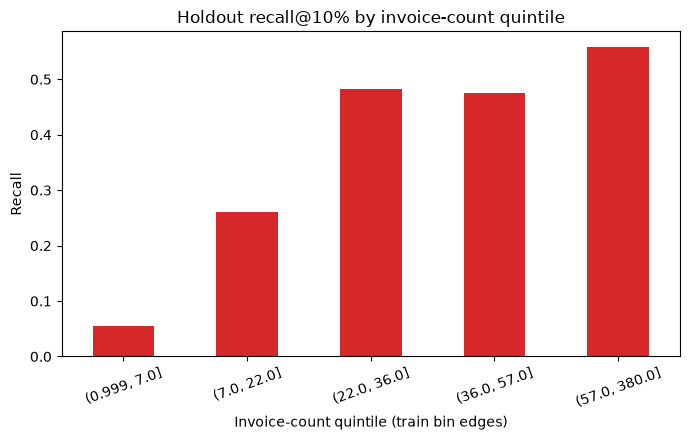

In [9]:
_, quintile_bin_edges = pd.qcut(df_train["invoice_count"], q=5, duplicates="drop", retbins=True)

df_test_segment = df_test.copy()
df_test_segment["invoice_count_quintile"] = pd.cut(
    df_test_segment["invoice_count"], bins=quintile_bin_edges, include_lowest=True
)
df_test_segment["flagged"] = holdout_flagged


def segment_recall(frame, column, minimum_fraud_cases=15):
    rows = []
    for segment_value, group in frame.groupby(column, dropna=False, observed=True):
        fraud_cases = int(group["target"].sum())
        if fraud_cases < minimum_fraud_cases:
            continue
        caught = int((group["flagged"] & (group["target"] == 1)).sum())
        rows.append({
            "segment": segment_value, "clients": len(group),
            "fraud_cases": fraud_cases, "recall": caught / fraud_cases,
        })
    return pd.DataFrame(rows)


print("Holdout recall by invoice-count quintile (bin edges from train):")
quintile_recheck = segment_recall(df_test_segment, "invoice_count_quintile")
display(quintile_recheck)

print("\nHoldout recall by region -- 104/107 flagged as hard, 311 as easy in 04's train-side analysis:")
region_recheck = segment_recall(df_test_segment, "region", minimum_fraud_cases=5)
display(region_recheck[region_recheck["segment"].isin([104, 107, 311])].sort_values("segment"))

fig, ax = plt.subplots(figsize=(7, 4.5))
quintile_recheck.sort_values("segment")["recall"].plot(
    kind="bar", ax=ax, color="#D62828",
)
ax.set_xticklabels([str(s) for s in quintile_recheck.sort_values("segment")["segment"]], rotation=20)
ax.set(title="Holdout recall@10% by invoice-count quintile", xlabel="Invoice-count quintile (train bin edges)", ylabel="Recall")
plt.tight_layout()
plt.show()

**What this shows:** both of `04`'s headline blind spots replicate on the untouched holdout, not
just in cross-validation. The shortest invoice-count quintile's holdout recall collapses to
**5.6%**, versus 26.1-55.9% for the other four quintiles -- the same severe short-history blind
spot `04_error_analysis.ipynb` found, now confirmed on clients the model-selection process never
saw. Region 104 (19.9% recall) and region 107 (29.1%) both stay weak, while region 311 (68.2%)
stays strong -- the exact pattern `04` flagged. Because the quintile bin edges and the flagging
threshold both came from training data only, this rules out "it was just this training split"
as an explanation: these are structural limitations of the current 15-feature contract, not
artifacts of how the development pool happened to be cut.

## Results

- **Tuning lift**: tuned LightGBM (`native categorical` preprocessing) reached development-pool CV
  PR-AUC **0.2473**, versus the untuned baseline's **0.2353** recomputed fresh
  in this notebook (`03_model_extension.ipynb`'s own historical number was 0.240, already seen to
  drift slightly across environments this project cycle).
- **Preprocessing variant**: `native categorical` won over the alternative on cross-validated
  PR-AUC by evidence, not by default.
- **Ensemble decision**: Declined. The soft LightGBM+Random Forest ensemble scored PR-AUC 0.2460 -- actually slightly *worse* than tuned LightGBM alone (0.2473), not just below the adoption margin. Consistent with `04_error_analysis.ipynb`'s finding of 71% identical verdicts across models: there wasn't enough complementary disagreement left for averaging to help, and it would have added complexity for a negative return.
- **Final, one-time holdout result** (`LightGBM (tuned, native-categorical preprocessing)`, fit on all of the development pool,
  scored once on `test_client_features.csv`): PR-AUC **0.2647**, ROC-AUC **0.8354**.
  Per Step 1's caveat, this is the final look at this split, not a fully untouched one -- 02
  already peeked at it once before the approach was frozen.
- **Did 04's blind spot replicate out-of-sample?** Yes, on every count -- see Step 8's analysis
  above for the full breakdown (short-history recall collapses to 5.6%; regions 104/107 stay
  weak while region 311 stays strong).

## Interpretation

Tuning delivered a modest, real lift over the untuned baseline (0.2473 vs. 0.2353 development-pool CV PR-AUC, roughly +5% relative) -- worth doing, but not a transformative change, consistent with `04`'s framing that the model's real limits are feature availability, not model configuration. LightGBM's native categorical handling edged out one-hot encoding by a small margin (0.2490 vs. 0.2478 CV PR-AUC) and was kept for its simpler pipeline (no one-hot dummy columns) as well as the score. The ensemble check is the clearest evidence-over-assumption result in this notebook: it was checked, not assumed, and the evidence said no. Most importantly, the holdout re-check in Step 8 confirms `04`'s headline finding is not an artifact of the training split -- the short-history blind spot and the region 104/107 weakness are real, structural limitations of the current 15-feature contract that hold up on genuinely unseen clients.

## Limitations

- **Any future iteration should prioritize new signal for short-history clients** (per `04`'s
  next-steps: relative/normalized features that don't require a long history) over further
  tuning of this model family -- this notebook tuned first and re-checked the blind spot
  afterward (see the caveat at the top of this notebook), rather than trying new features first
  as `04` recommended. That recommendation is still outstanding.
- The holdout evaluation is a final look, not a pristine untouched one (Step 1); `02` already
  used the same split for a preliminary baseline check.
- Hyperparameter search covered 30 random draws per preprocessing variant, not an exhaustive
  grid -- a wider or Bayesian search (e.g. Optuna, used by the external Zindi reference solution
  `03_model_extension.ipynb` cites) might find further gains, at a cost this project's dependency
  set doesn't currently include.
- The short-history blind spot `04_error_analysis.ipynb` identified is a feature-availability
  problem, not something hyperparameter tuning can fix -- `04`'s own deeper Steps 10-14 found the
  bulk of the miss (92.9%) isn't even explained by short history at all, and tuning alone
  wouldn't be expected to close that gap. It remains the most important limitation of this model,
  regardless of the tuning/ensemble decisions made here.